## K Means Clustering
- K-Means is an unsupervised machine learning algorithm used to group similar data points into K clusters.
- It works by partitioning the dataset into K distinct, non-overlapping groups based on similarity (usually distance).

### How K-Means Works ?
1. Randomly pick K points as the initial cluster centroids.
2. Assign each data point to the nearest centroid.
3. Recalculate the centroid of each cluster i.e adjust the centroid with respect to data points.
4. Repeat the process until cluster assignment dont change (Centroids converge).

### How to Pick K ?
 - To pick K there is well known method called **"Elbow method"** by which we can select the value for **K**.

### How Elbow Method Works ?
1. Run K-Means clustering on the data for different values of K (e.g., from 1 to 10).
2.  For each K, calculate the SSE (Sum of Squared Errors) — also called inertia

$$
\text{WCSS} = \sum_{i=1}^{K} \sum_{x \in C_i} \| x - \mu_i \|^2
$$

**Where**:
- Ci = cluster i
- u =  centroid of cluster 𝑖
- x = data points

3. Plot K vs SSE.
4. Look for the "elbow" point in the curve — where the SSE starts to decrease more slowly.


In [3]:
import pandas as pd
df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [9]:
from matplotlib import pyplot as plt
%matplotlib inline

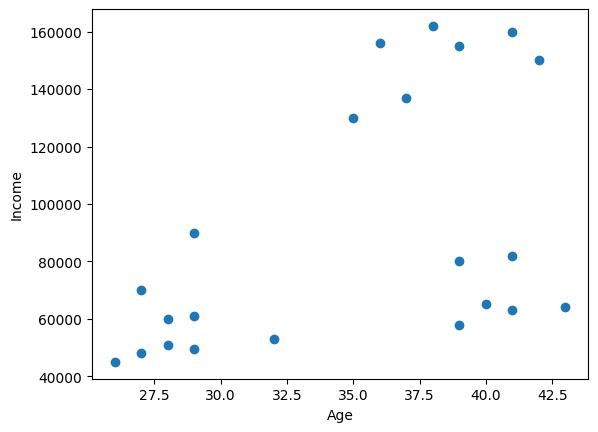

In [10]:
# lets draw plot
plt.scatter(df['Age'], df['Income($)'])
plt.xlabel("Age")
plt.ylabel("Income")
plt.show()

In [15]:
# lets do K means
from sklearn.cluster import KMeans
km = KMeans(n_clusters=3)
km

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [16]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [20]:
df['cluster'] = y_predicted
df.head()

,Name,Age,Income($),cluster
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [21]:
km.cluster_centers_

array([[3.29090909e+01, 5.61363636e+04],
       [3.82857143e+01, 1.50000000e+05],
       [3.40000000e+01, 8.05000000e+04]])

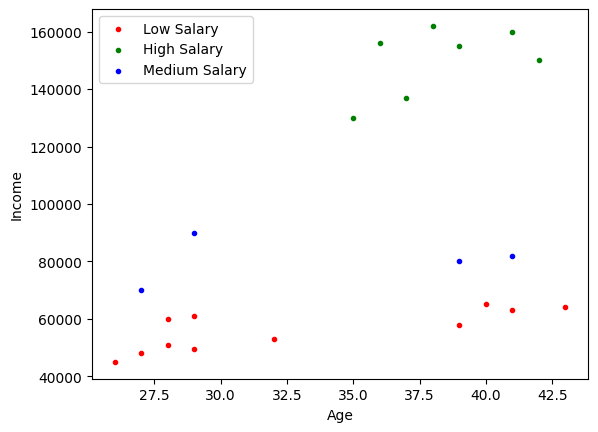

In [24]:
# Lets create dfs and create scatter plot
df0 = df[df['cluster'] == 0]
df1 = df[df['cluster'] == 1]
df2 = df[df['cluster'] == 2]
plt.scatter(df0['Age'], df0['Income($)'], color='red', marker='.', label="Low Salary")
plt.scatter(df1['Age'], df1['Income($)'], color='green', marker='.', label="High Salary")
plt.scatter(df2['Age'], df2['Income($)'], color='blue', marker='.', label="Medium Salary")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.show()

- it seems like clustering did not happend properly
- but that's not the case, this happend because the x and y range is quite far, it should be equaly distributed.


In [25]:
### Preprocessing using min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [31]:
scaler.fit(df[['Age']])
df['Age'] = scaler.fit_transform(df[['Age']])

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.fit_transform(df[['Income($)']])  # range from 0 to 1

df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,2
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


In [33]:
y_predicted = km.fit_predict(df[['Age', 'Income($)']])
y_predicted

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [34]:
df['cluster'] = y_predicted

In [35]:
df.head()

,Name,Age,Income($),cluster
0,Rob,0.058824,0.213675,0
1,Michael,0.176471,0.384615,0
2,Mohan,0.176471,0.136752,0
3,Ismail,0.117647,0.128205,0
4,Kory,0.941176,0.897436,1


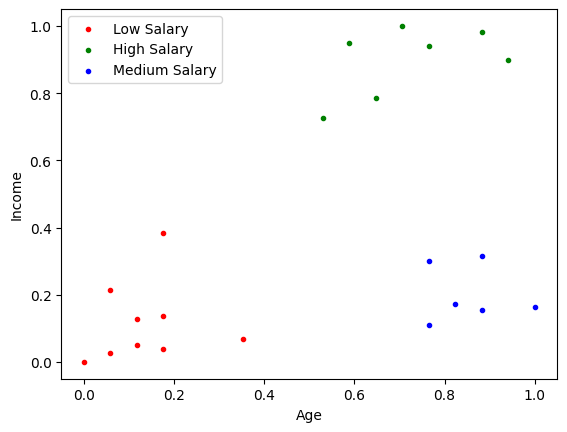

In [36]:
# Lets create dfs and create scatter plot
df0 = df[df['cluster'] == 0]
df1 = df[df['cluster'] == 1]
df2 = df[df['cluster'] == 2]
plt.scatter(df0['Age'], df0['Income($)'], color='red', marker='.', label="Low Salary")
plt.scatter(df1['Age'], df1['Income($)'], color='green', marker='.', label="High Salary")
plt.scatter(df2['Age'], df2['Income($)'], color='blue', marker='.', label="Medium Salary")
plt.xlabel("Age")
plt.ylabel("Income")
plt.legend()
plt.show()

In [38]:
### Let's plot Elbow Plot
sse = []
for i in range(1,10):
    km = KMeans(n_clusters=i)
    km.fit_predict(df[['Age','Income($)']])
    sse.append(km.inertia_)

print(sse)

[5.434011511988177, 2.3456144914725936, 0.47507834985530945, 0.42015522057314414, 0.32657706599188674, 0.2779193542740477, 0.20555281537743908, 0.15771437581577172, 0.12116842693470026]


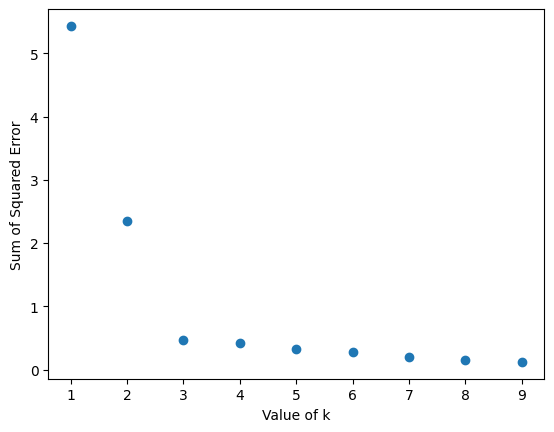

In [39]:
# lets plot
k_range = range(1,10)
plt.scatter(k_range, sse)
plt.xlabel("Value of k")
plt.ylabel("Sum of Squared Error")
plt.show()

- we can clearly see, 3 kinda looks like elbow